# Statistická práce - NBA

## Načtení dat a připravení prostředí

Pro statistickou práci jsem si zvolil 2 datasety s historickými NBA daty z Kaggle. Navzdory tomu, že datasety mají velký průnik, tak každý z nich obsahuje další unikátní data. Oba datasety převážně používají stejné id z oficiální NBA API, tedy se dají datasety částečně kombinovat.

In [57]:
%pip install kagglehub numpy pandas matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
import kagglehub
import os

# Download latest version
nba_dataset1 = kagglehub.dataset_download(
    "eoinamoore/historical-nba-data-and-player-box-scores",
    output_dir=os.path.join(".data", "NBA Dataset Box Scores and Stats (1947 - Today)")
)
nba_dataset2 = kagglehub.dataset_download(
    "wyattowalsh/basketball",
    output_dir=os.path.join(".data", "NBA_Database")
)

## Odpočinek mezi zápasy

Jako první test budeme zkoumat zda existuje vztah mezi opočinkem (doba mezi zápasy) a pravděpodobností výhry.

Data budeme zpracovávat následovně. Rozdělíme si data do tříd podle počtu dnů odpočinku pro tým a následně pro každou z těchto tříd spočítáme pravděpodobnost výhry. 

In [59]:
from collections import defaultdict

import pandas

class Team:
    def __init__(self, team_id, team_name):
        self.team_id = team_id
        self.team_name = team_name

    def __str__(self):
        return f"Team ID: {self.team_id}, Team Name: {self.team_name}"

games = pandas.read_csv(os.path.join(".data", "NBA_Database", "csv", "game.csv"))
teams_details = pandas.read_csv(os.path.join(".data", "NBA_Database", "csv", "team.csv"))

teams = [Team(team_id, team_name) for team_id, team_name in zip(teams_details["id"], teams_details["full_name"])]

class Counter:
    def __init__(self):
        self.count = 0
        self.wins = 0

    def increment(self):
        self.count += 1

    def win(self):
        self.wins += 1
        self.increment()
    
    def lose(self):
        self.increment()

time_to_win = defaultdict(Counter)

for team in teams:
    games_iter = list(games[(games["team_id_home"] == team.team_id) | (games["team_id_away"] == team.team_id)].sort_values(by="game_date").iterrows())

    for (_, pref), (_, curr) in zip(games_iter, games_iter[1:]):
        date_diff = pandas.to_datetime(curr["game_date"]) - pandas.to_datetime(pref["game_date"])

        if (curr["team_id_home"] == team.team_id and curr["wl_home"] == "W") or (curr["team_id_away"] == team.team_id and curr["wl_away"] == "W"):
            time_to_win[date_diff.days].win()
        else:
            time_to_win[date_diff.days].lose()





Při porovnávání dat se omezíme pouze na délku odpočinku menší než 10 dnů, poněvadž delší odpočinky jsou v NBA vzácné a mnohokrát spíše indikují anomálii v datech a nevyskytují se tak často, aby dávali rozumný pravděpodobnostní odhad. 

Ověřmě pomocí lineární regrese zda existuje lineární vztah mezi dobou odpočinku a pravděpodobnost výhry. Z grafu/dat můžeme uděláš závěr, že existuje korelace mezi tím, že když tým mám více času na odpočinek, tak má větší pravděpodobnost výhry. Dále můžeme vyčíst, že hlavní nárůst/rozdíl je v prvních pár dnech, tedy je velký rozdíl, zda tým hraje jeden zápas za druhým, nebo má 1 či 2 dny přestávku.

Tedy existuje vztah mezi odpočinek a pravděpodobnostní výhry, ale nemůžeme říct, že je úplně lineární na intervalu odpočinku do 10 dnů. Ale můžeme z dat vyčíst, že lineární vztah poměrně dobře popisuje pravděpodobnost výhry v závislosti na odpočinku pro délku odpočinku 0, 1 nebo 2 dnů.

Obecně by se dalo předpokládat, že při zvyšujícím se počtu dnů odpočinku přestane tato metrika hrát roli a pravděpodobnost výhry bude konvergovat k 50+ %, což už můžeme pozorovat častečně i z našeho datasetu. 

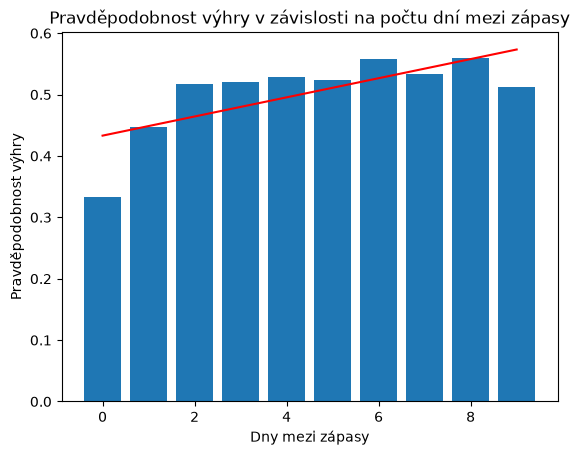

In [60]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

fig, ax = plt.subplots()
days = list(key for key in time_to_win.keys() if key < 10)
win_rate = [time_to_win[day].wins / time_to_win[day].count if time_to_win[day].count > 0 else 0 for day in days]

x_line = np.linspace(min(days), max(days), 100)
result = linregress(days, win_rate)

y_line = result.slope * x_line + result.intercept

ax.plot(
    x_line,
    y_line,
    label=f"y = {result.slope:.2f}x + {result.intercept:.2f}",
    color="red"
)

ax.bar(days, win_rate)
ax.set_xlabel("Dny mezi zápasy")
ax.set_ylabel("Pravděpodobnost výhry")
ax.set_title("Pravděpodobnost výhry v závislosti na počtu dní mezi zápasy")
plt.show()

# Nejlepší hráč v týmu

V tomto testu chceme zjistit, zda existuje závislost mezi tím, kolik procentuálně bodů v teamu získal nejlepší hráč a jak se týmu dařilo. 

Data zpracujeme tak, že každý poměrně $\frac{\text{nejlepší}}{\text{soucet}}$ ohodnotíme historicky zda s tímto průměrem vyhrávalo nebo prohrávalo, tedy součet přes všechny hry s tímto součtem, za výhru +1 a za prochu -1.

In [61]:
games_combined = games.merge(pandas.read_csv(os.path.join(".data", "NBA Dataset Box Scores and Stats (1947 - Today)", "Games.csv"), low_memory=False), left_on="game_id", right_on="gameId", how="inner")

player_stats = pandas.read_csv(os.path.join(".data", "NBA Dataset Box Scores and Stats (1947 - Today)", "PlayerStatisticsExtended.csv"), low_memory=False)

In [62]:
unique_pairs = player_stats[['gameId','playerteamId']].drop_duplicates().reset_index(drop=True)

data_points = []

for _, row in unique_pairs.iterrows():
    game_id = row['gameId']
    team_id = row['playerteamId']
    
    team_player_stats = player_stats[(player_stats['gameId'] == game_id) & (player_stats['playerteamId'] == team_id)]

    max_points = team_player_stats['points'].max()
    sum_points = team_player_stats['points'].sum()
    won = team_player_stats['win'].iloc[0] == 1 if not team_player_stats.empty else None

    if max_points is not None and max_points > 0:
        data_points.append((max_points, sum_points, won))


Pokud bychom použili jako třídy/osu-x pouze určité poměrý tak bychom narazili, že určité poměry se v historii vyskytli pouze parkrát, tedy hodnoty nejsou vypovídající, viz graf níže. 

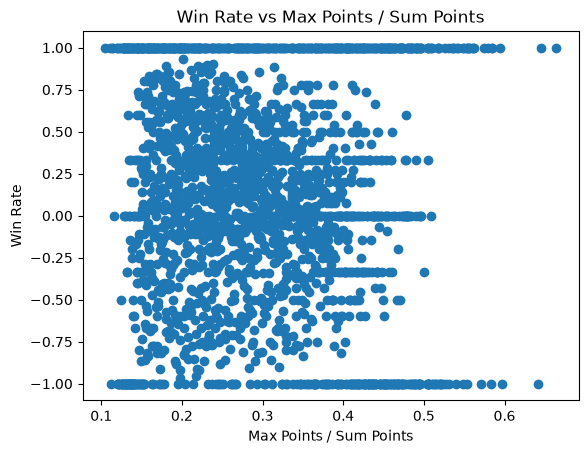

In [63]:
x_axis = [m / s if s != 0 else 0 for m, s, _ in data_points]
y_axis = [1 if won else -1 for _, _, won in data_points]

grouped = defaultdict(list)
for x, y in zip(x_axis, y_axis):
    grouped[x].append(y)

x_aggregated = list(grouped.keys())
y_aggregated = [sum(values) / len(values) for values in grouped.values()]

fig, ax = plt.subplots()
ax.scatter(x_aggregated, y_aggregated)
ax.set_xlabel("Max Points / Sum Points")
ax.set_ylabel("Win Rate")
ax.set_title("Win Rate vs Max Points / Sum Points")
plt.show()

Problém s třídami můžeme vyřešit 2 přístupy. První je, že si rozdělíme třídy, díky tomu, že nabívá hodnot pouze od 0 do 1, na konečné množství stejně velkých tříd. Nebo druhý přístup je rozdělit třídy do konečně mnoha skupin, tak že se snažíme, aby každá skupina měla stený počet tříd, na tento přístup se můžeme např. při rozdělení na 100 skupin jako na percentily.

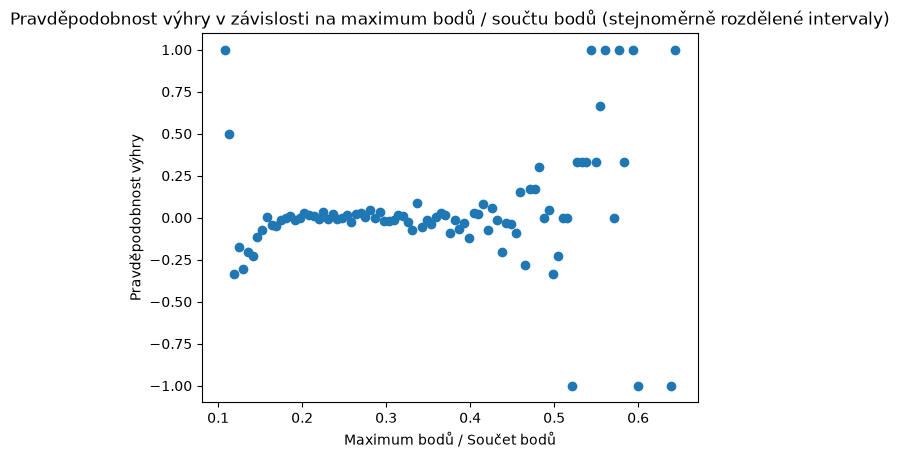

In [64]:
intervals = 100

x_min = min(x_axis)
x_max = max(x_axis)
bin_edges = np.linspace(x_min, x_max, intervals + 1) 
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

bins_dict = {i: [] for i in range(intervals)}
for x, y in zip(x_axis, y_axis):
    bin_idx = np.digitize(x, bin_edges) - 1
    if 0 <= bin_idx < intervals:
        bins_dict[bin_idx].append(y)

x_binned = []
y_binned = []
for i in range(intervals):
    if bins_dict[i]:  
        x_binned.append(bin_centers[i])
        y_binned.append(sum(bins_dict[i]) / len(bins_dict[i]))

fig, ax = plt.subplots()
ax.scatter(x_binned, y_binned)
ax.set_xlabel("Maximum bodů / Součet bodů")
ax.set_ylabel("Pravděpodobnost výhry")
ax.set_title(f"Pravděpodobnost výhry v závislosti na maximum bodů / součtu bodů (stejnoměrně rozdělené intervaly)")
plt.show()


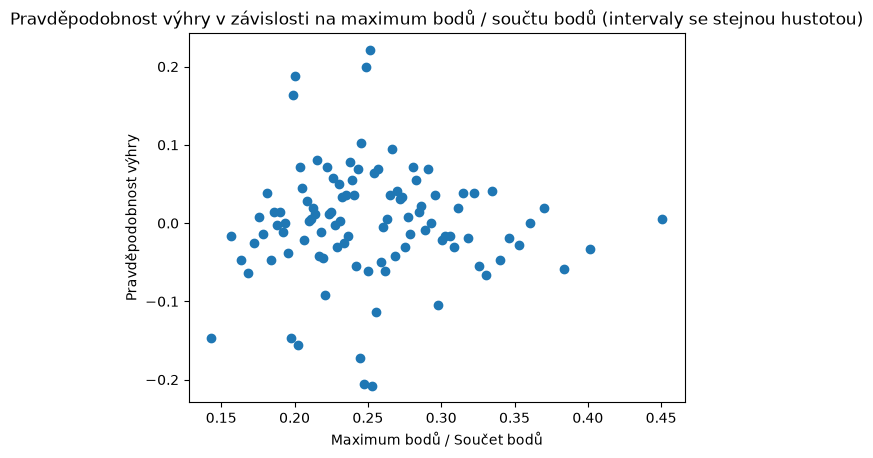

In [65]:
intervals = 100

sorted_indices = np.argsort(x_axis)
bin_size = len(x_axis) // intervals

x_binned = []
y_binned = []

for i in range(intervals):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < intervals - 1 else len(x_axis)
    
    if start_idx < len(x_axis):
        bin_indices = sorted_indices[start_idx:end_idx]
        bin_x = [x_axis[j] for j in bin_indices]
        bin_y = [y_axis[j] for j in bin_indices]
        
        if bin_x:  
            x_binned.append(np.mean(bin_x))
            y_binned.append(np.mean(bin_y))

fig, ax = plt.subplots()
ax.scatter(x_binned, y_binned)
ax.set_xlabel("Maximum bodů / Součet bodů")
ax.set_ylabel("Pravděpodobnost výhry")
ax.set_title(f"Pravděpodobnost výhry v závislosti na maximum bodů / součtu bodů (intervaly se stejnou hustotou)")
plt.show()


Jak můžeme nahlédnout nejlepší vhled nám dá přístup k rozdělením na stejnou hustotu, poněvadž rozdělní na stejné části je silně ovlivněno extrémy. 

Z dat nejde přímo vyvodit, že by byl nějaký vztah mezi tím, že by hry vyhrávali tymy, které by měli výrazně nejlepšího hráče. Jediné, kde toto můžeme trochu nahlédnout, tak je na extrémech, tedy když jeden hráč představuje 50+ % všech bodů týmu, což nejspíše implikuje velmi dobrou hru pro jednoho hráče a v tomto případě můžeme pozorovat hlavně z prvního a druhého grafu, že v těchto případech je pravděpodobnější, že tým vyhraje.  

## Vyplatí se trojky

V tomto testu budeme sledovat zda se více vyplatí pro hráče pokoušet se o náročnější střelu za 3 body, nebo jednoduší za 2 body. Tedy zajímá nás očekávaná hodnota za hody. 

In [66]:
play_by_play = pandas.read_csv(os.path.join(".data", "NBA_Database", "csv", "play_by_play.csv"))

In [67]:

def analyse_shoots(play_by_play):
    pt3_made, pt3_attempt = 0, 0
    pt2_made, pt2_attempt = 0, 0

    for _, row in play_by_play.iterrows():
        if (isinstance(row["homedescription"], str) and "3PT" in row["homedescription"]) or (isinstance(row["visitordescription"], str) and "3PT" in row["visitordescription"]):
            pt3_attempt += 1
            pt3_made += 1 if row["eventmsgtype"] == 1 else 0
        else:
            pt2_attempt += 1
            pt2_made += 1 if row["eventmsgtype"] == 1 else 0

    return pt3_made, pt3_attempt, pt2_made, pt2_attempt

In [ ]:
pt3_made, pt3_attempt, pt2_made, pt2_attempt = analyse_shoots(play_by_play[play_by_play["eventmsgtype"].isin([1,2])])

print(f"3PT Made: {pt3_made}, 3PT Attempted: {pt3_attempt}, 3PT Percentage: {pt3_made/pt3_attempt*100:.2f}%, 2PT Made: {pt2_made}, 2PT Attempted: {pt2_attempt}, 2PT Percentage: {pt2_made/pt2_attempt*100:.2f}%")

3PT Made: 456693, 3PT Attempted: 1284106, 3PT Percentage: 35.57% 2PT Made: 1785664, 2PT Attempted: 3657627, 2PT Percentage: 48.82%


Z historických dat můžeme vidět, že navzdory tomu, že trojkový hod má nižší pravděpodobnost úspěchu, tak díky tomu, že je za něj více bodů, tak se v průměru vyplatí více než dvojkový hod. 

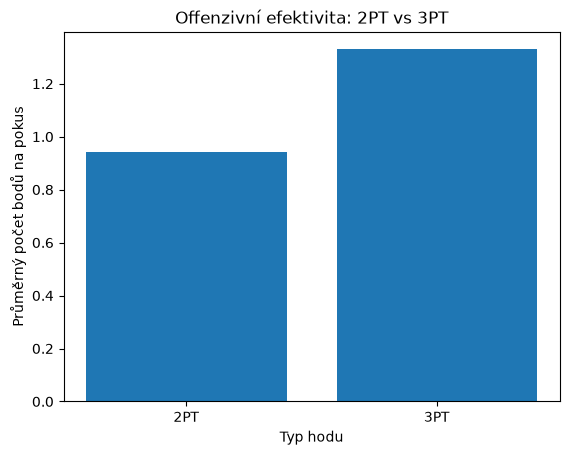

In [74]:
fig, ax = plt.subplots()
ax.bar(["2PT", "3PT"], [pt2_made/pt2_attempt*2, pt3_made/pt3_attempt*3])
ax.set_xlabel("Typ hodu")
ax.set_ylabel("Průměrný počet bodů na pokus")
ax.set_title(f"Offenzivní efektivita: 2PT vs 3PT")
plt.show()

In [ ]:
teams = teams = play_by_play["player1_team_id"].dropna().unique()

shoots_per_team = {}

for team in teams:
    team_play_by_play = play_by_play[play_by_play["player1_team_id"] == team]
    pt3_made, pt3_attempt, pt2_made, pt2_attempt = analyse_shoots(team_play_by_play[team_play_by_play["eventmsgtype"].isin([1,2])])

    shoots_per_team[team] = (pt3_made, pt3_attempt, pt2_made, pt2_attempt)

[1.61061275e+09 1.61061276e+09 1.61061275e+09 1.61061274e+09
 1.61061275e+09 1.61061274e+09 1.61061274e+09 1.61061275e+09
 1.61061274e+09 1.61061276e+09 1.61061274e+09 1.61061274e+09
 1.61061276e+09 1.61061275e+09 1.61061274e+09 1.61061274e+09
 1.61061276e+09 1.61061275e+09 1.61061275e+09 1.61061276e+09
 1.61061276e+09 1.61061276e+09 1.61061275e+09 1.61061276e+09
 1.61061275e+09 1.61061276e+09 1.61061277e+09 1.61061276e+09
 1.61061276e+09 1.61061683e+09 1.61061683e+09 1.61061274e+09
 1.23210000e+04 1.23240000e+04 1.23080000e+04 9.30000000e+01
 4.10000000e+01 1.23230000e+04 1.23250000e+04 9.40000000e+01
 1.23280000e+04 1.23150000e+04 1.23290000e+04 1.23040000e+04
 1.23300000e+04 1.50180000e+04 1.50150000e+04 1.50160000e+04
 1.50170000e+04 5.00090000e+04 1.50190000e+04]
Team ID: 1610612747.0 - 3PT Made: 15873, 3PT Attempted: 45584, 3PT Percentage: 34.82% 2PT Made: 64800, 2PT Attempted: 129876, 2PT Percentage: 49.89%
Average points per game: 84.59
Team ID: 1610612756.0 - 3PT Made: 16490, 

Můžeme ještě zpracovat, zda pravidlo o lepší volbě trojkového hodu platí i na úrovni týmů. Z grafu níže můžeme výčíst, že až na ojedinělé výjimky, tak se z historických dat týmům více vyplatili trojkové hody.

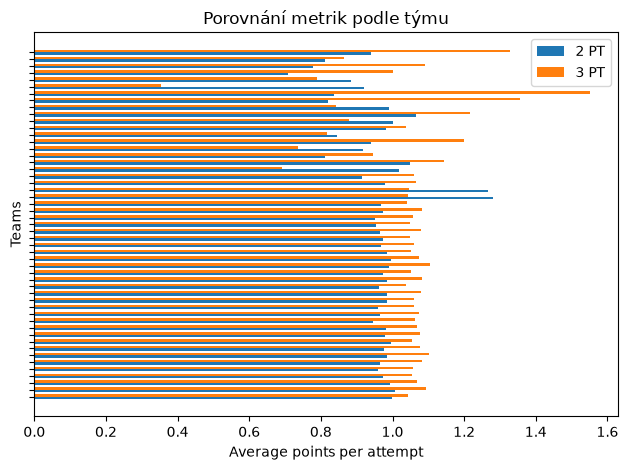

In [ ]:
x_axis = shoots_per_team.keys()
x = np.arange(len(x_axis))  
width = 0.35             

fig, ax = plt.subplots()
ax.tick_params(axis="y", labelleft=False)
plt.barh(x - width/2, [pt2_made / pt2_attempt * 2 for _, _, pt2_made, pt2_attempt in shoots_per_team.values()], width, label="2 PT")
plt.barh(x + width/2, [pt3_made / pt3_attempt * 3 for pt3_made, pt3_attempt, _, _ in shoots_per_team.values()], width, label="3 PT")

plt.yticks(x, x_axis)
plt.xlabel("Průměrný počet bodů na pokus")
plt.ylabel("Týmy")
plt.title("Porovnání metrik podle týmu")
plt.legend()

plt.tight_layout()
plt.show()

## Rozdělení výšky hráčů

V tomto testu budeme ověřovat zda rozložení výšek hráčů v NBA odpovídá normálnímu rozdělení.

Při vizualizaci si můžeme povšimnout, že histogram výšek hráčů do určité míry kopíruje normální rozdělení, ale dochází k poměrně velkým odchylkám u střední hodnoty. 

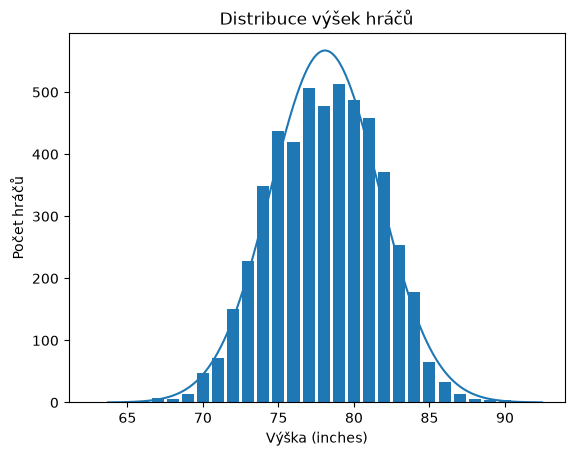

In [109]:
from scipy.stats import norm, chi2

players = pandas.read_csv(os.path.join(".data", "NBA Dataset Box Scores and Stats (1947 - Today)", "Players.csv"))

heights = players["heightInches"].value_counts().sort_index()

mean = np.average(heights.index, weights=heights.values)
var = np.average((heights.index - mean)**2, weights=heights.values)

x = np.linspace(mean - 4*np.sqrt(var), mean + 4*np.sqrt(var), 1000)
y = norm.pdf(x, mean, np.sqrt(var)) * heights.values.sum()

fig, ax = plt.subplots()
ax.bar(heights.index, heights.values)
ax.plot(x, y)
ax.set_xlabel("Výška (inches)")
ax.set_ylabel("Počet hráčů")
ax.set_title("Distribuce výšek hráčů")
plt.show()


Využijme $\chi^2$ test pro zjištění, zda rozdělení výšek odpovídá normálnímu rozdělení. 

Prvně provedeme $\chi^2$ test, kde budeme kontrolovat každou výšku v datasetu jako jednu kategorii. V tomto případě dostáváme, že p-hodnota je $7.17\times 10^{-13}$. Při takovémto množství tříd může být $\chi^2$ test poměrně dost přísný, vytvořme si v druhém testu skupiny tříd a zkontrolujme zda i v takovémto případě zamítneme. 

Při rozdělení výšek do intervalů $\left( -\infty, 73.5\right ], \left( 73.5, 78.5 \right], \left(78.5, 83.5 \right], \left(83.5, \infty \right]$ dostáváme trochu příznivější p-hodnotu 0.003, ale pořád bychom na hladině 0.95 zamítáme.

In [138]:
intervals = [-float("inf")] + [h + 0.5 for h in heights.index.tolist()[:-1]] + [float("inf")]

chi = 0
for a, b, val in zip(intervals[:-1], intervals[1:], heights.values):
    exp = (norm.cdf(b, mean, np.sqrt(var)) - norm.cdf(a, mean, np.sqrt(var))) * heights.values.sum()
    chi += (val - exp)**2 / exp

    #print(a, b, val, (val - exp)**2 / exp)

print(f"p-hodnota: {chi2.sf(chi, len(heights) - 3)}")

p-hodnota: 7.1676260298845e-13


In [139]:
thresholds = [-float("inf"), 73.5, 78.5, 83.5, float("inf")]
data = []
for x, y in zip(thresholds[:-1], thresholds[1:]):
    c = 0

    for idx, val in heights.items():
        if x < idx <= y:
            c += val

    data.append(c)

chi = 0
intervals = thresholds
for a, b, val in zip(intervals[:-1], intervals[1:], data):
    exp = (norm.cdf(b, mean, np.sqrt(var)) - norm.cdf(a, mean, np.sqrt(var))) * heights.values.sum()
    chi += (val - exp)**2 / exp

    #print(a, b, val, (val - exp)**2 / exp)

print(f"p-hodnota: {chi2.sf(chi, len(intervals) - 3)}")

p-hodnota: 0.0032849696402118974
